# Space Weather Analysis

Space weather analysis: understand the physical meaning of every selected variable.

# Space Weather Analysis

This notebook investigates the physical relationships between the solar wind,
interplanetary magnetic field (IMF), and geomagnetic activity using the
NASA OMNI dataset.

The objective is to understand the physical structure of the time series
before defining the forecasting problem for Time-Series Foundation Models.

We focus on:

- Solar-wind plasma conditions
- Interplanetary magnetic field (IMF)
- Geomagnetic activity
- Solar-wind–magnetosphere coupling
- Temporal response and delays
- Candidate forecasting targets and predictors

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/omni2_2016_2025_clean.csv',
    parse_dates=["datetime"]
)

df = df.sort_values("datetime").set_index("datetime")

df.head()

,year,doy,hour,B_scalar_nT,Bx_nT,By_gse_nT,Bz_gse_nT,By_gsm_nT,Bz_gsm_nT,temperature_K,density_cm3,speed_km_s,flow_pressure_nPa,electric_field_mV_m,plasma_beta,alfven_mach,Kp10,Dst_nT,AE_nT
datetime,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,2016,1,0,15.0,4.9,-1.5,-14.1,2.2,-14.0,32589.0,2.0,463.0,0.88,6.48,0.06,2.2,60,-116,686
2016-01-01 01:00:00,2016,1,1,14.6,5.7,-2.2,-13.2,1.1,-13.3,30566.0,0.8,451.0,0.33,6.04,0.02,1.4,60,-114,574
2016-01-01 02:00:00,2016,1,2,13.9,4.5,-1.8,-13.0,1.1,-13.1,29278.0,1.1,450.0,0.45,5.89,0.04,1.7,60,-102,788
2016-01-01 03:00:00,2016,1,3,13.5,2.9,0.7,-13.1,3.1,-12.8,18090.0,1.7,434.0,0.64,5.60,0.06,2.1,53,-98,710
2016-01-01 04:00:00,2016,1,4,13.1,3.0,0.3,-12.7,2.0,-12.5,10371.0,0.9,430.0,0.33,5.42,0.03,1.6,53,-96,909


## Interplanetary Magnetic Field (IMF) and Coordinate Systems
The Interplanetary Magnetic Field (IMF) is the solar magnetic field carried by the solar wind. The OMNI dataset provides magnetic-field components in different coordinate systems:
- **GSE (Geocentric Solar Ecliptic):** X points towards the Sun, Z is parallel to the ecliptic pole.
- **GSM (Geocentric Solar Magnetospheric):** X points towards the Sun, but the X-Z plane contains the Earth's magnetic dipole axis.

**Why GSM?** GSM is particularly useful for interpreting solar-wind–magnetosphere coupling because the interaction depends heavily on the orientation of the incoming IMF relative to the Earth's tilted magnetic dipole.

## The Importance of IMF Bz
The north-south component of the IMF in GSM coordinates (`Bz_GSM`) is a critical parameter.
- **Northward IMF (positive Bz):** Generally weak coupling.
- **Southward IMF (negative Bz):** When Bz is directed southward, it opposes the Earth's northward-pointing dayside magnetic field. Conceptually, this allows for **magnetic reconnection**, effectively opening the magnetosphere and allowing solar-wind energy to transfer into the Earth's system. Negative Bz provides favorable conditions for stronger solar-wind–magnetosphere coupling.

## Solar-Wind Variables
- **Speed:** Describes the bulk radial velocity of the solar wind. Sustained high-speed streams transport immense kinetic energy. The strong persistence observed in Notebook 01 makes physical sense because high-speed streams can sweep past Earth for days.
- **Density:** Describes the concentration of solar-wind protons. Density often exhibits short-lived, dramatic spikes; therefore, its mean alone does not adequately describe storm behavior.
- **Temperature:** Characterizes the thermal state of the solar wind. 

**Fundamental vs. Derived Quantities:**
The dataset contains explicitly measured fundamental variables (Speed, Density, B-field) as well as derived quantities:
- **Flow/Dynamic Pressure:** Proportional to density × speed².
- **Convective Electric Field:** Derived from $V \times B_z$.
- **Plasma Beta & Alfvén Mach Number.**
We clearly distinguish these because while derived features highlight physical thresholds, they are mathematically constructed from the fundamental measurements.

# Geomagnetic Response

The solar wind provides the external forcing, while geomagnetic indices
describe different aspects of Earth's response to that forcing.

## Geomagnetic Indices: The Response
**Dst (Disturbance Storm Time):** Measures the intensity of the equatorial ring current. An intensifying ring current generates a magnetic field opposing Earth's, causing Dst to drop. A sudden drop marks the main phase, reaching a minimum, followed by a slow recovery phase. More negative Dst = stronger disturbance.

**Kp Index:** A 3-hour planetary index measuring global geomagnetic disturbance. In OMNI, it is multiplied by 10. Because it is a 3-hour aggregated metric, its plotted time series looks step-like.

**AE (Auroral Electrojet):** Measures high-latitude geomagnetic activity driven by auroral-zone currents.

*Note:* We will not attempt to build forecasting models for Kp or AE here. Dst is our primary forecasting target.

In [2]:
df["Bz_gsm_nT"].nsmallest(20)

datetime
2024-10-10 23:00:00   -42.2
2024-10-11 00:00:00   -39.4
2024-05-11 00:00:00   -35.3
2024-05-11 09:00:00   -35.2
2024-05-10 21:00:00   -35.0
2024-05-11 01:00:00   -34.0
2025-11-12 01:00:00   -32.6
2023-04-24 02:00:00   -32.4
2023-04-24 03:00:00   -30.9
2024-10-11 03:00:00   -28.9
2024-10-11 04:00:00   -28.9
2024-10-11 02:00:00   -28.5
2023-04-24 04:00:00   -28.0
2024-10-11 01:00:00   -27.6
2024-05-10 20:00:00   -26.9
2023-04-24 05:00:00   -26.6
2024-10-11 05:00:00   -25.9
2017-09-08 00:00:00   -24.2
2023-11-05 10:00:00   -23.4
2024-05-11 03:00:00   -22.8
Name: Bz_gsm_nT, dtype: float64

In [3]:
df["Dst_nT"].nsmallest(20)

datetime
2024-05-11 02:00:00   -406
2024-05-11 03:00:00   -395
2024-05-11 01:00:00   -390
2024-05-11 04:00:00   -389
2024-05-11 07:00:00   -374
2024-05-11 08:00:00   -364
2024-05-11 05:00:00   -358
2024-05-10 22:00:00   -339
2024-10-11 01:00:00   -333
2024-05-11 06:00:00   -320
2024-05-11 10:00:00   -318
2024-05-11 00:00:00   -313
2024-10-11 00:00:00   -309
2024-05-10 23:00:00   -308
2024-10-10 23:00:00   -303
2024-05-11 09:00:00   -297
2024-10-11 02:00:00   -296
2024-10-11 03:00:00   -283
2024-05-11 14:00:00   -281
2024-05-11 13:00:00   -279
Name: Dst_nT, dtype: int64

In [4]:
df["Kp10"].nlargest(20)

datetime
2024-05-11 00:00:00    90
2024-05-11 01:00:00    90
2024-05-11 02:00:00    90
2024-05-11 09:00:00    90
2024-05-11 10:00:00    90
2024-05-11 11:00:00    90
2024-05-10 18:00:00    87
2024-05-10 19:00:00    87
2024-05-10 20:00:00    87
2024-05-10 21:00:00    87
2024-05-10 22:00:00    87
2024-05-10 23:00:00    87
2024-05-11 12:00:00    87
2024-05-11 13:00:00    87
2024-05-11 14:00:00    87
2024-10-10 21:00:00    87
2024-10-10 22:00:00    87
2024-10-10 23:00:00    87
2025-11-12 00:00:00    87
2025-11-12 01:00:00    87
Name: Kp10, dtype: int64

## Event Analysis: May 10–11, 2024

The extreme-value analysis identifies May 10–11, 2024 as a strong
geomagnetic disturbance.

During this period:

- IMF Bz_GSM reaches strongly negative values.
- Dst reaches a pronounced negative excursion.
- Kp reaches the maximum value represented in the dataset (Kp = 9).

We examine the event at hourly resolution to investigate the temporal
relationship between solar-wind conditions and geomagnetic response.

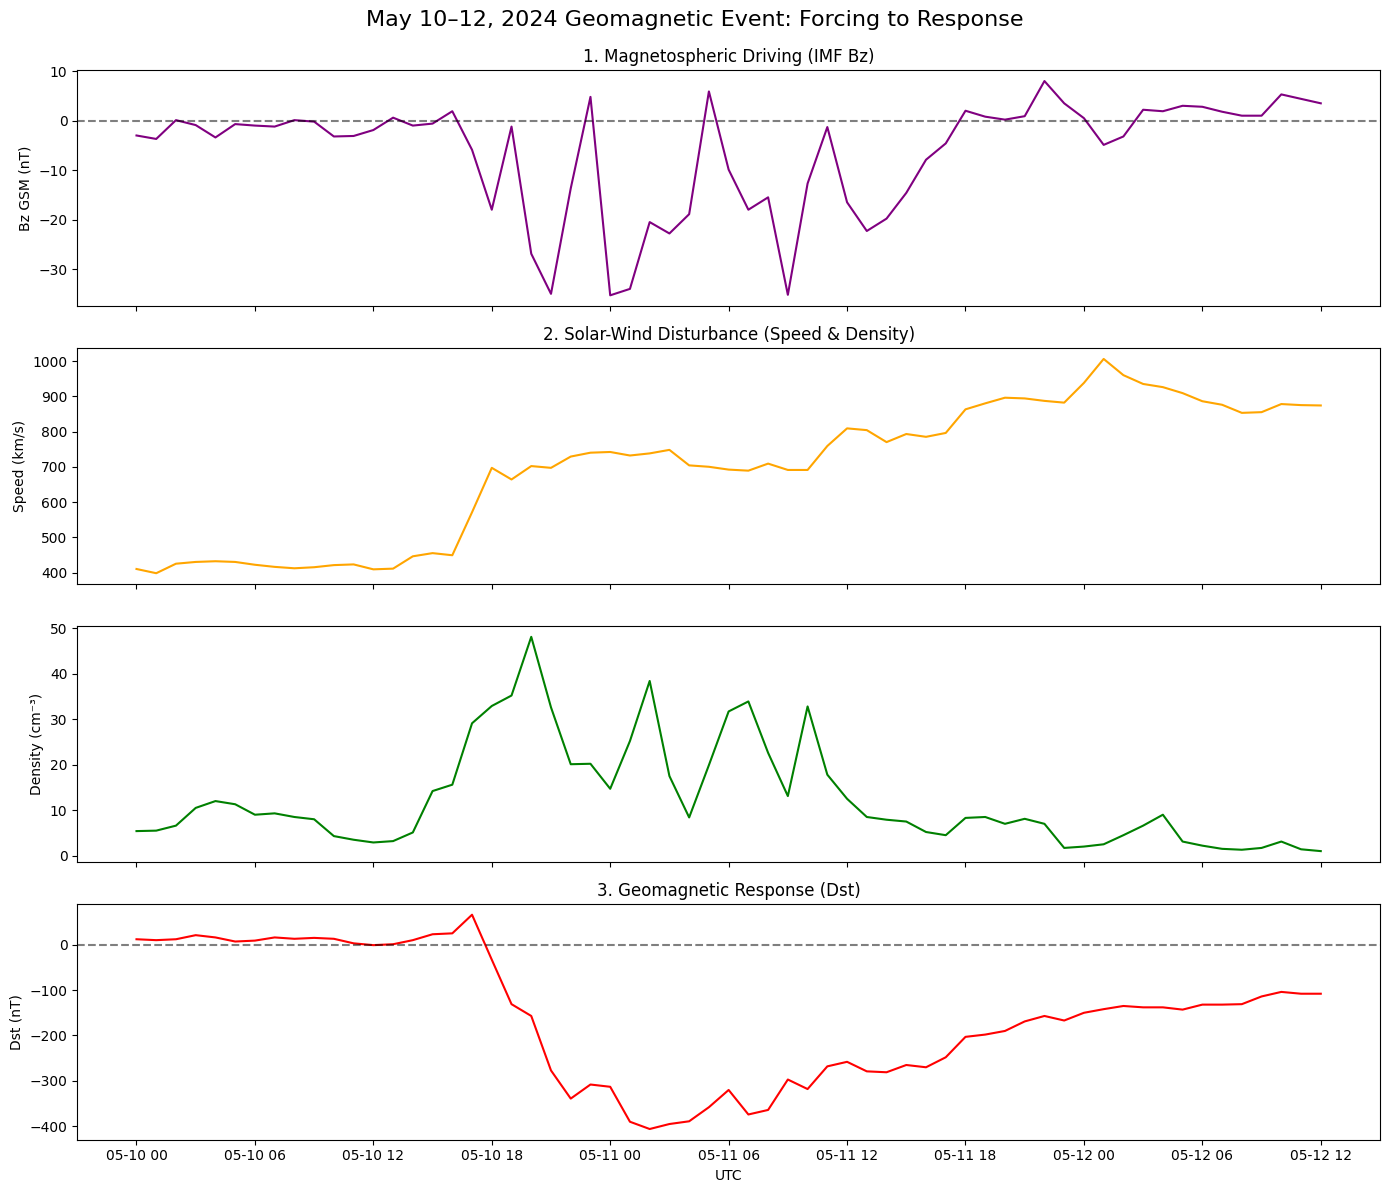

In [5]:
event = df.loc["2024-05-10 00:00":"2024-05-12 12:00"]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle("May 10–12, 2024 Geomagnetic Event: Forcing to Response", y=0.99, fontsize=16)

# Magnetospheric Driving
axes[0].plot(event.index, event["Bz_gsm_nT"], color='purple')
axes[0].axhline(0, linestyle="--", color='black', alpha=0.5)
axes[0].set_ylabel("Bz GSM (nT)")
axes[0].set_title("1. Magnetospheric Driving (IMF Bz)")

# Solar-wind disturbance
axes[1].plot(event.index, event["speed_km_s"], color='orange')
axes[1].set_ylabel("Speed (km/s)")
axes[1].set_title("2. Solar-Wind Disturbance (Speed & Density)")

axes[2].plot(event.index, event["density_cm3"], color='green')
axes[2].set_ylabel("Density (cm⁻³)")

# Geomagnetic Response
axes[3].plot(event.index, event["Dst_nT"], color='red')
axes[3].axhline(0, linestyle="--", color='black', alpha=0.5)
axes[3].set_ylabel("Dst (nT)")
axes[3].set_title("3. Geomagnetic Response (Dst)")
axes[3].set_xlabel("UTC")

plt.tight_layout()
plt.show()

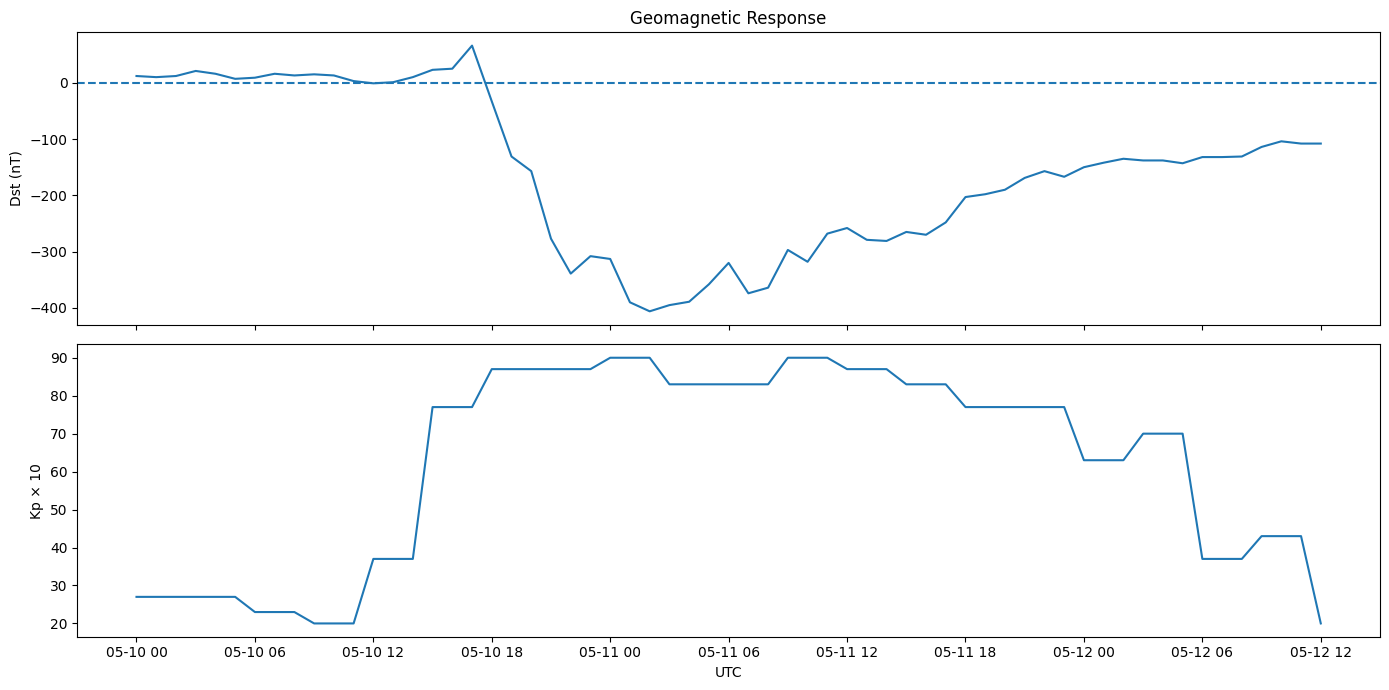

In [6]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 7),
    sharex=True
)

axes[0].plot(event.index, event["Dst_nT"])
axes[0].axhline(0, linestyle="--")
axes[0].set_ylabel("Dst (nT)")
axes[0].set_title("Geomagnetic Response")

axes[1].plot(event.index, event["Kp10"])
axes[1].set_ylabel("Kp × 10")
axes[1].set_xlabel("UTC")

plt.tight_layout()
plt.show()

In [7]:
event = df.loc["2024-05-10 00:00":"2024-05-12 12:00"].copy()

lags = range(1,25)
correlations=[]
for lag in lags:
    x=event["Bz_gsm_nT"]
    y=event["Dst_nT"].shift(-lag)
    valid=x.notna() & y.notna()
    correlations.append(x[valid].corr(y[valid]))
lag_corr=pd.DataFrame({
    "lag_hours":list(lags),
    "correlation":correlations
})
lag_corr

,lag_hours,correlation
0,1,0.650973
1,2,0.606252
2,3,0.595515
3,4,0.625724
4,5,0.586002
5,6,0.557980
6,7,0.553029
7,8,0.461925
8,9,0.369503
9,10,0.345633


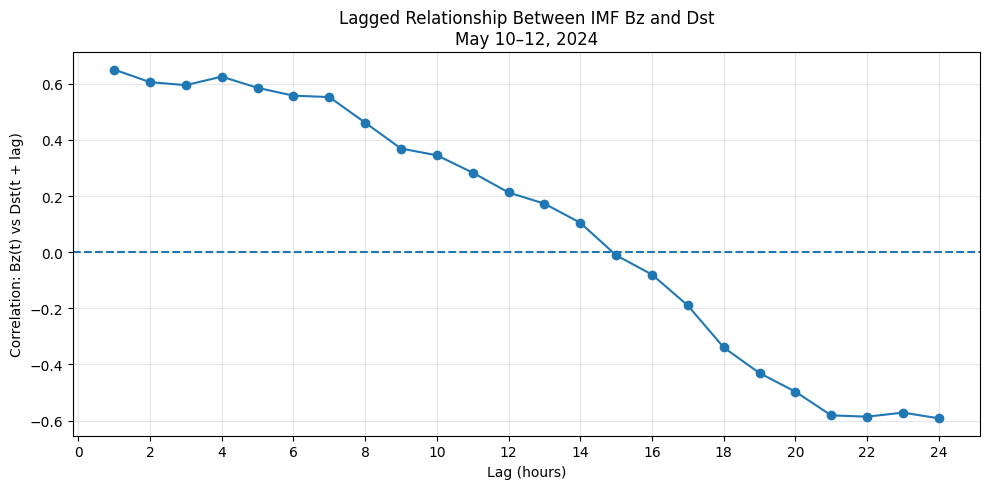

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(
    lag_corr["lag_hours"],
    lag_corr["correlation"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Lag (hours)")
plt.ylabel("Correlation: Bz(t) vs Dst(t + lag)")
plt.title("Lagged Relationship Between IMF Bz and Dst\nMay 10–12, 2024")

plt.xticks(range(0, 25, 2))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Event-Specific Lagged Correlation Interpretation
The plot above shows strong positive correlation at short lags (~0.6–0.65), dropping to zero around 15 hours, and becoming highly negative (~-0.6) at long lags. 

**Important:** This sign reversal should NOT be interpreted as a universal physical law (e.g., "there is a universal 24-hour negative physical response to Bz"). Instead, this is an **event-specific statistical pattern** strongly influenced by the shape of this particular storm: the sudden main phase, the long Dst recovery, the changing Bz state, and temporal autocorrelation. It is an exploratory visualization of temporal association for this specific timeline.

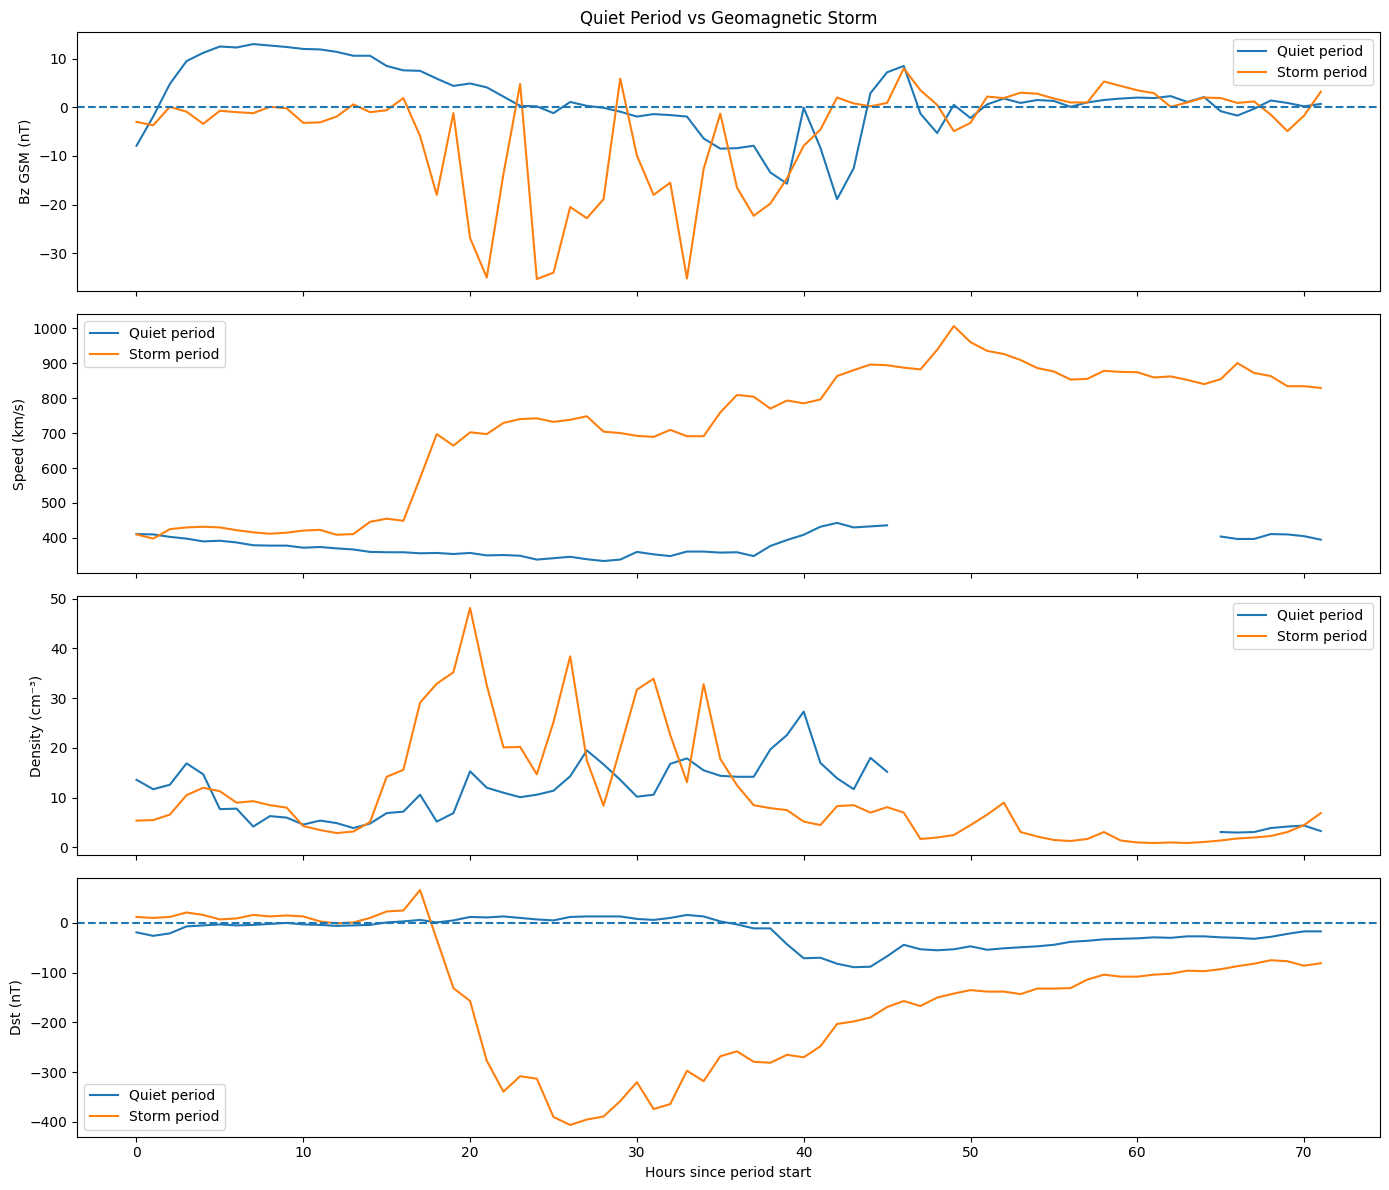

In [9]:
quiet = df.loc["2024-05-01 00:00":"2024-05-03 23:00"].copy()
storm = df.loc["2024-05-10 00:00":"2024-05-12 23:00"].copy()

quiet["hours"] = np.arange(len(quiet))
storm["hours"] = np.arange(len(storm))
fig, axes = plt.subplots(
    4, 1,
    figsize=(14, 12),
    sharex=True
)

# Bz
axes[0].plot(
    quiet["hours"],
    quiet["Bz_gsm_nT"],
    label="Quiet period"
)

axes[0].plot(
    storm["hours"],
    storm["Bz_gsm_nT"],
    label="Storm period"
)

axes[0].axhline(0, linestyle="--")
axes[0].set_ylabel("Bz GSM (nT)")
axes[0].set_title("Quiet Period vs Geomagnetic Storm")
axes[0].legend()

# Speed
axes[1].plot(
    quiet["hours"],
    quiet["speed_km_s"],
    label="Quiet period"
)

axes[1].plot(
    storm["hours"],
    storm["speed_km_s"],
    label="Storm period"
)

axes[1].set_ylabel("Speed (km/s)")
axes[1].legend()

# Density
axes[2].plot(
    quiet["hours"],
    quiet["density_cm3"],
    label="Quiet period"
)

axes[2].plot(
    storm["hours"],
    storm["density_cm3"],
    label="Storm period"
)

axes[2].set_ylabel("Density (cm⁻³)")
axes[2].legend()

# Dst
axes[3].plot(
    quiet["hours"],
    quiet["Dst_nT"],
    label="Quiet period"
)

axes[3].plot(
    storm["hours"],
    storm["Dst_nT"],
    label="Storm period"
)

axes[3].axhline(0, linestyle="--")
axes[3].set_ylabel("Dst (nT)")
axes[3].set_xlabel("Hours since period start")
axes[3].legend()

plt.tight_layout()
plt.show()

In [10]:
comparison = pd.DataFrame({
    "Quiet period": [
        quiet["Bz_gsm_nT"].mean(),
        quiet["speed_km_s"].mean(),
        quiet["density_cm3"].mean(),
        quiet["Dst_nT"].mean()
    ],
    "Storm period": [
        storm["Bz_gsm_nT"].mean(),
        storm["speed_km_s"].mean(),
        storm["density_cm3"].mean(),
        storm["Dst_nT"].mean()
    ]
}, index=[
    "Mean Bz GSM (nT)",
    "Mean speed (km/s)",
    "Mean density (cm^-3)",
    "Mean Dst (nT)"
])

comparison

,Quiet period,Storm period
Mean Bz GSM (nT),1.438889,-5.294444
Mean speed (km/s),377.716981,719.833333
Mean density (cm^-3),10.954717,10.855556
Mean Dst (nT),-19.763889,-145.916667


### Quiet vs Storm: Connecting Data to Physics
The comparison demonstrates that a geomagnetic storm is a multivariate physical phenomenon:
- **Observation:** `Bz_GSM` becomes strongly negative (Storm ≈ -5.29 nT).
  **Physics:** Southward IMF is favorable for stronger solar-wind–magnetosphere coupling.
- **Observation:** Speed rises dramatically (Storm ≈ 719.8 km/s).
  **Physics:** The solar-wind regime has become strongly disturbed/high-speed.
- **Observation:** Mean density is almost identical, but the storm plots show massive transient enhancements.
  **Physics:** Similar mean density does not imply similar behavior; short-lived density shocks drive dynamic pressure.
- **Observation:** `Dst` falls heavily (Storm ≈ -145.92 nT).
  **Physics:** This represents a severe geomagnetic disturbance and an enhanced ring current.

## Physics to Forecasting Connection
Understanding these physical variables motivates our next steps in forecasting.

A simple **univariate** forecasting model only sees the statistical history of the target:
`[Dst history] → [Future Dst]`

However, our physical analysis shows that storms are driven by multivariate solar-wind changes. A **multivariate** model can potentially leverage this external physical forcing:
`[Bz, speed, density, pressure, Dst] → [Future Dst]`

By establishing the dataset structure (Notebook 01) and the physical meaning behind that structure (Notebook 02), we are now prepared to properly define baselines and evaluate Time-Series Foundation Models.